# Customer Segmentation Analysis Using K-Means Clustering

## Objective:
 To apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.


## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
%matplotlib inline

## Loading the Dataset

In [2]:
df=pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Dataset Inspection

In [3]:
print("Dataset Shape:",df.shape)

Dataset Shape: (1067371, 8)


In [4]:
print("Dataset Columns:")
print(df.columns)

Dataset Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


### Observation
- The dataset contains transaction-level information of an e-commerce company.
- It includes customer details, invoice information, product descriptions, purchase quantities, prices, and transaction dates.
- Some columns may contain missing values, which will be handled in the data cleaning stage.
- The `InvoiceDate` column will later be converted to datetime format for RFM analysis.

## Missing Value Analysis

In [7]:
print("Missing Values Count")
mv=df.isnull().sum()
mv

Missing Values Count


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
print("Missing Value Percentage")
mvp=(df.isnull().sum()/len(df))*100
mvp.sort_values(ascending=False)

Missing Value Percentage


Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

### Observation
- The `Customer ID` column contains approximately **22.77%** missing values.
- The `Description` column contains only **0.41%** missing values.
- All other columns have **no missing values**, indicating that the transactional data is largely complete.
- Since customer segmentation relies on identifying individual customers, rows with missing `Customer ID` values will be removed before performing the RFM analysis.

## Data Cleaning
- Since the missing values are customer IDs and Descriptions we cannot replace them with mean or mode values of overall dataset, so we are going to drop them.

In [9]:
df=df.dropna(subset="Customer ID")

In [10]:
df = df.dropna(subset=['Description'])

In [11]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)
df = df.drop_duplicates()

Duplicate Rows: 26479


In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (797885, 8)

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [14]:
print("Cleaned Shape:", df.shape)

Cleaned Shape: (797885, 8)


### Observation

- Records with missing `Customer ID` and `Description` values were removed because they are essential for customer segmentation.
- Duplicate records were removed to improve data quality.
- The `InvoiceDate` column was converted to datetime format to enable time-based calculations for the RFM analysis.
- The cleaned dataset is now ready for feature engineering and clustering.

## Descriptive Statistics

In [15]:
df["Total Amount"]=df["Quantity"]*df["Price"]
df[["Quantity","Price","Total Amount"]].head()

,Quantity,Price,Total Amount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [16]:
df[["Quantity","Price","Total Amount"]].describe()

,Quantity,Price,Total Amount
count,797885.000000,797885.000000,797885.000000
mean,12.602980,3.702732,20.416465
std,191.670371,71.392549,313.518824
min,-80995.000000,0.000000,-168469.600000
25%,2.000000,1.250000,4.350000
50%,5.000000,1.950000,11.700000
75%,12.000000,3.750000,19.500000
max,80995.000000,38970.000000,168469.600000


### Observation
- The descriptive statistics summarize the distribution of purchase quantity, product price, and total transaction amount.
- These metrics provide an overview of customer purchasing behavior and transaction values.
- The calculated Total Amount will be used to estimate customer spending in the RFM analysis.

## Customer Behaviour Statistics

In [17]:
print("Average Purchase Value of Customers:")
avg_purchase=df.groupby("Customer ID")["Total Amount"].mean()
avg_purchase.head()

Average Purchase Value of Customers:


Customer ID
12346.0    -1.100851
12347.0    22.169054
12348.0    39.596078
12349.0    24.469667
12350.0    19.670588
Name: Total Amount, dtype: float64

In [18]:
print("Purchase Frequency of Customers:")
purchase_frequency=df.groupby("Customer ID")["Invoice"].nunique()
purchase_frequency.head()

Purchase Frequency of Customers:


Customer ID
12346.0    17
12347.0     8
12348.0     5
12349.0     5
12350.0     1
Name: Invoice, dtype: int64

In [19]:
print("Lifetime Value of a Customer:")
customer_lifetime_value=df.groupby("Customer ID")["Total Amount"].sum()
customer_lifetime_value.head()

Lifetime Value of a Customer:


Customer ID
12346.0     -51.74
12347.0    4921.53
12348.0    2019.40
12349.0    4404.54
12350.0     334.40
Name: Total Amount, dtype: float64

In [20]:
print("Combined Dataset for Customer Behaviour Statistics:")
customer_stats = pd.DataFrame({
    'Average Purchase Value': avg_purchase,
    'Purchase Frequency': purchase_frequency,
    'Customer Lifetime Value': customer_lifetime_value
})
customer_stats.head()

Combined Dataset for Customer Behaviour Statistics:


,Average Purchase Value,Purchase Frequency,Customer Lifetime Value
Customer ID,,,
12346.0,-1.100851,17,-51.74
12347.0,22.169054,8,4921.53
12348.0,39.596078,5,2019.40
12349.0,24.469667,5,4404.54
12350.0,19.670588,1,334.40


### Observation
- Average Purchase Value represents the average amount spent by each customer per transaction.
- Purchase Frequency indicates how often each customer makes purchases.
- Customer Lifetime Value represents the total revenue generated by each customer during the recorded period.
- These behavioural metrics provide valuable insights into customer purchasing patterns and will serve as the foundation for customer segmentation.

## RFM Feature Engineering
 **From RFM Analysis we are going to know:**
- Recency(R)-How recently the customer purchased?
- Frequency(F)-How recently the customer is purchasing?
- Monetory(M)-How much money the customer spent?

In [21]:
latest_date=df["InvoiceDate"].max() #This will be a reference date to calculate recency.
print("Latest Invoice Date:",latest_date)

Latest Invoice Date: 2011-12-09 12:50:00


In [22]:
rfm=df.groupby('Customer ID').agg({
    'InvoiceDate' : lambda x:(latest_date-x.max()).days,
    'Invoice':'nunique',
     'Total Amount':'sum'})
rfm.columns=['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,17,-51.74
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,5,4404.54
12350.0,309,1,334.40


In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000
mean,201.908617,7.552339,2741.499712
std,211.857936,15.972262,13676.639629
min,0.000000,1.000000,-25111.090000
25%,24.000000,2.000000,321.065000
50%,95.000000,4.000000,822.010000
75%,380.000000,8.000000,2142.195000
max,738.000000,510.000000,570380.610000


### Observation
- Three behavioural features were created for each customer: **Recency**, **Frequency**, and **Monetary (RFM)**.
- **Recency** measures how recently a customer made a purchase.
- **Frequency** represents the number of unique purchases made by each customer.
- **Monetary** indicates the total amount spent by each customer.
- These features provide the basis for customer segmentation using the K-Means clustering algorithm.

## Data Standardization

In [24]:
rfm_features=rfm[["Recency","Frequency","Monetary"]]
scalar= StandardScaler()
rfm_scaled=scalar.fit_transform(rfm_features)
pd.DataFrame(rfm_scaled,columns=["Recency","Frequency","Monetary"]).head()

,Recency,Frequency,Monetary
0,0.581058,0.591554,-0.204252
1,-0.948397,0.028030,0.159412
2,-0.603798,-0.159812,-0.052802
3,-0.868148,-0.159812,0.121607
4,0.505529,-0.410267,-0.176016


### Observation
- The RFM features were standardized using **StandardScaler**.
- Standardization ensures that all features have a similar scale, preventing features with larger values from dominating the clustering process.
- The standardized dataset is now ready for K-Means clustering.

## Elbow Method

In [31]:
import os
print(os.cpu_count())

12


In [33]:
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

In [36]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)


### Plot

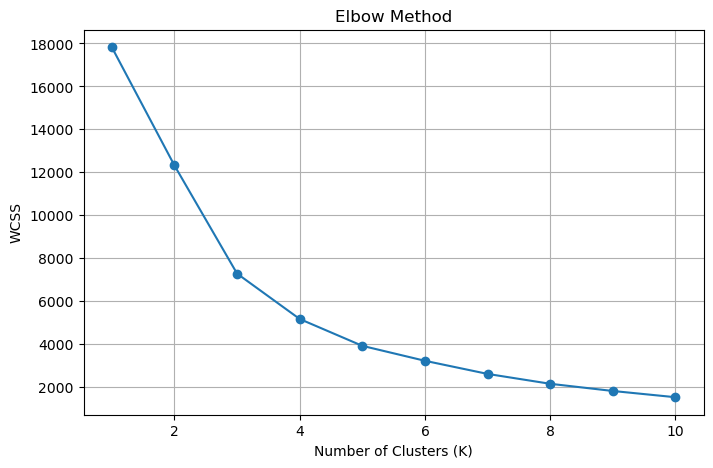

In [26]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Observation
- The Elbow Method was used to determine the optimal number of clusters.
- A sharp decrease in WCSS was observed up to **K = 4**.
- After **K = 4**, the reduction in WCSS became gradual, indicating diminishing improvements.
- Therefore, **4 clusters** were selected for customer segmentation using the K-Means algorithm.

## K-Means Clustering

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,325,17,-51.74,0
12347.0,1,8,4921.53,1
12348.0,74,5,2019.40,1
12349.0,18,5,4404.54,1
12350.0,309,1,334.40,0


In [28]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    2037
1    3859
2       4
3      42
Name: count, dtype: int64

### Observation
- Customers were grouped into **4 distinct clusters** using the K-Means algorithm.
- Each customer was assigned to the cluster with the nearest centroid based on the standardized RFM features.
- These clusters represent different purchasing behaviours and will be analysed further to identify customer profiles.

## Cluster Visualizations

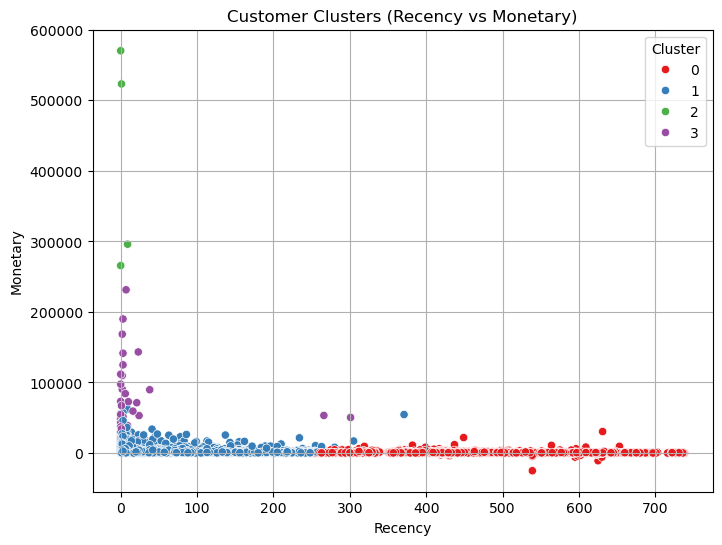

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)
plt.title('Customer Clusters (Recency vs Monetary)')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.grid(True)
plt.show()

### Observation
- The scatter plot shows how customers are distributed based on their recency and monetary value.
- Customers with lower recency and higher monetary value represent recent high-value customers.
- Different colors indicate different customer segments identified by the K-Means algorithm.

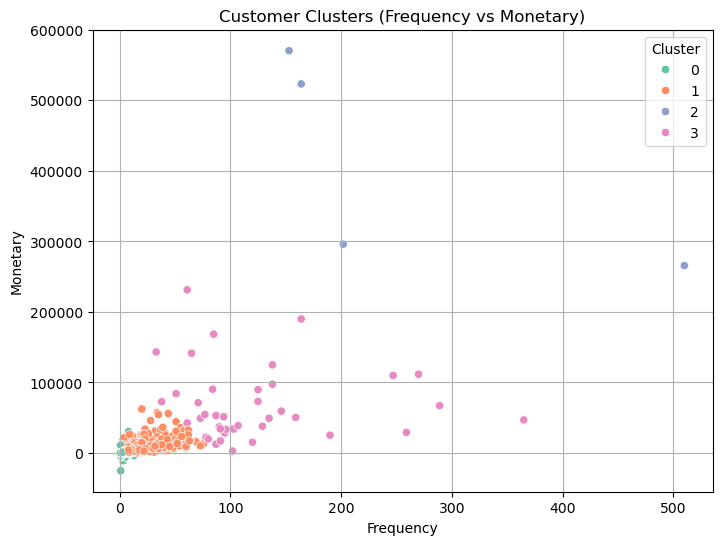

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)
plt.title('Customer Clusters (Frequency vs Monetary)')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.grid(True)
plt.show()

### Observation
- The scatter plot illustrates the relationship between purchase frequency and total spending.
- Customers with higher purchase frequency generally contribute higher revenue.
- The clusters clearly separate customers with different purchasing behaviours.

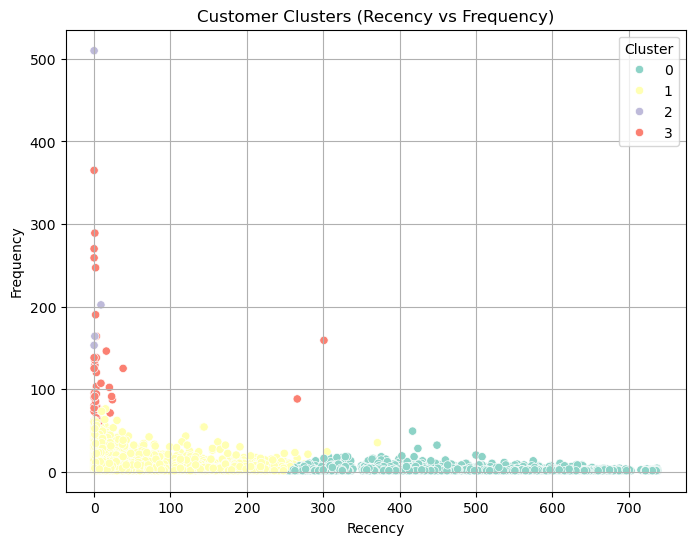

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set3'
)
plt.title('Customer Clusters (Recency vs Frequency)')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Observation
- This scatter plot shows the relationship between how recently customers made purchases and how frequently they purchase.
- Customers with low recency and high frequency are generally the most active and loyal.
- Customers with high recency and low frequency may be inactive and could be targeted with re-engagement campaigns.

## Cluster Profile

In [38]:
cluster_profile = rfm.groupby('Cluster').mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,465.260187,2.579283,606.487861
1,65.092770,8.688261,2749.896282
2,2.500000,257.250000,413886.007500
3,19.119048,120.595238,66361.469833


## Customers per Cluster

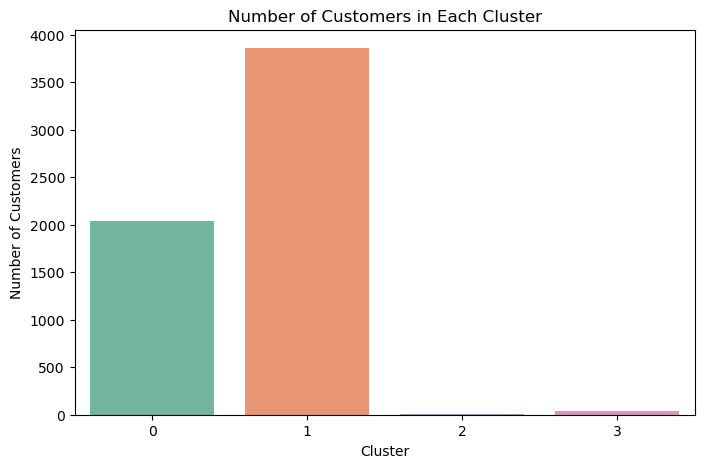

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Cluster',
    data=rfm,
    palette='Set2'
)
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

### Observation
- The bar chart shows the number of customers assigned to each cluster.
- It helps understand the size of each customer segment.
- This information can assist businesses in prioritizing marketing strategies for different customer groups.
- Highest number of customers are in **cluster 1** and **cluster 2** have a significant amount of customers.
- **Cluster 2 and 3** have a very less amount of customers.

In [41]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,465.260187,2.579283,606.487861
1,65.092770,8.688261,2749.896282
2,2.500000,257.250000,413886.007500
3,19.119048,120.595238,66361.469833


### Cluster Profile
- **Cluster 0 – Inactive / Lost Customers**
  - Highest recency, lowest purchase frequency, and lowest spending.
  - These customers have not made purchases for a long time and may require re-engagement.
- **Cluster 1 – Regular Customers**
  - Moderate recency, purchase frequency, and spending.
  - These customers contribute steady revenue and can be encouraged to purchase more frequently.
- **Cluster 2 – VIP Customers**
  - Lowest recency, highest purchase frequency, and highest spending.
  - These are the most valuable customers and should receive premium services and exclusive rewards.
- **Cluster 3 – Loyal Customers**
  - Low recency, high purchase frequency, and high spending.
  - These customers are loyal buyers who should be retained through personalized offers and loyalty programs.

## Marketing Recommendations
- **Cluster 0 – Inactive / Lost Customers**
  - Launch re-engagement campaigns through emails, discount coupons, and special offers to encourage repeat purchases.
- **Cluster 1 – Regular Customers**
  - Offer personalized product recommendations and bundle discounts to increase purchase frequency and spending.
- **Cluster 2 – VIP Customers**
  - Provide exclusive membership benefits, early access to new products, and premium customer support to retain these high-value customers.
- **Cluster 3 – Loyal Customers**
  - Reward loyalty through points-based programs, referral bonuses, and personalized appreciation offers to maintain long-term engagement.

# Conclusion
- This project successfully segmented customers into four distinct groups using the K-Means clustering algorithm based on Recency, Frequency, and Monetary (RFM) analysis.
- The Elbow Method was used to determine the optimal number of clusters, and StandardScaler was applied to standardize the features before clustering. - - The resulting customer segments revealed significant differences in purchasing behaviour, allowing businesses to identify inactive customers, regular customers, loyal customers, and high-value VIP customers.
- These insights can help businesses design targeted marketing strategies, improve customer retention, and maximize revenue through personalized campaigns.